# **Name : Shahab Khan**
# Reg NO : SP24-BCS-112



# **Task 1 — Apply BFS and DFS on Tree & Graph**

In [6]:
from collections import deque

# Tree Example
tree = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F', 'G'],
    'D': [],
    'E': [],
    'F': [],
    'G': []
}

def bfs_tree(graph, start):
    visited = []
    queue = deque([start])

    while queue:
        node = queue.popleft()
        if node not in visited:
            visited.append(node)
            queue.extend(graph[node])

    return visited


def dfs_tree(graph, start):
    visited = []
    stack = [start]

    while stack:
        node = stack.pop()
        if node not in visited:
            visited.append(node)
            stack.extend(reversed(graph[node]))

    return visited


print("Tree BFS:", bfs_tree(tree, 'A'))
print("Tree DFS:", dfs_tree(tree, 'A'))


# Graph Example
graph = {
    1: [2,3],
    2: [1,4,5],
    3: [1,6],
    4: [2],
    5: [2,6],
    6: [3,5]
}

def bfs_graph(graph, start):
    visited = set()
    queue = deque([start])

    while queue:
        node = queue.popleft()
        if node not in visited:
            visited.add(node)
            queue.extend(graph[node])

    return visited


def dfs_graph(graph, start):
    visited = set()
    stack = [start]

    while stack:
        node = stack.pop()
        if node not in visited:
            visited.add(node)
            stack.extend(graph[node])

    return visited


print("Graph BFS:", bfs_graph(graph, 1))
print("Graph DFS:", dfs_graph(graph, 1))

Tree BFS: ['A', 'B', 'C', 'D', 'E', 'F', 'G']
Tree DFS: ['A', 'B', 'D', 'E', 'C', 'F', 'G']
Graph BFS: {1, 2, 3, 4, 5, 6}
Graph DFS: {1, 2, 3, 4, 5, 6}


# **Task 2 — Large Data + BFS DFS Timing + DataFrame + Bar Chart**

Running for: 1000
Running for: 40000
Running for: 80000
Running for: 200000
Running for: 1000000

Result DataFrame:

   Input Size  BFS Time  DFS Time
0        1000  0.000437  0.000167
1       40000  0.016153  0.011376
2       80000  0.041218  0.026318
3      200000  0.110997  0.034395
4     1000000  0.665838  0.029100


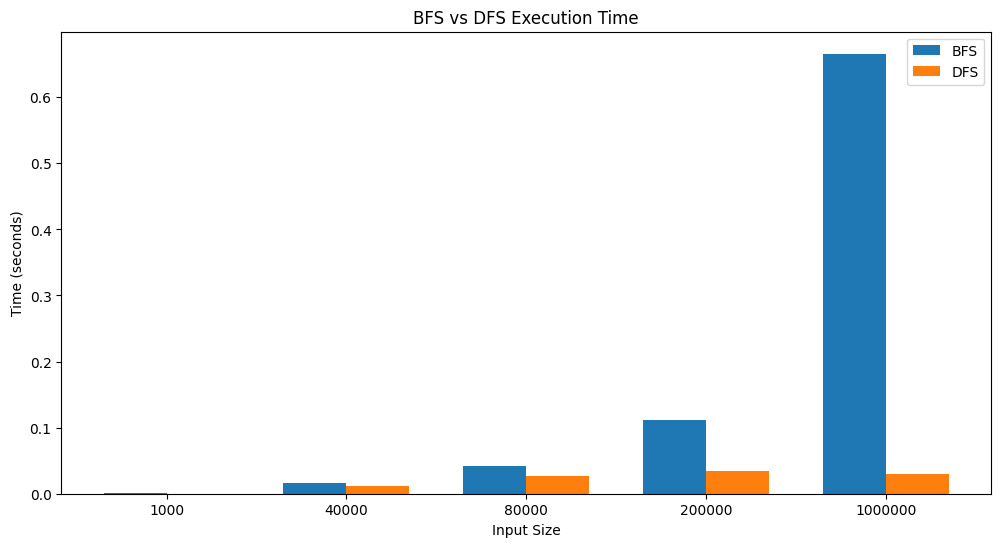

In [7]:
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque
import numpy as np


# Function to build tree from list
def build_tree(lst):
    tree = {}
    for i in range(len(lst)):
        children = []
        left = 2*i + 1
        right = 2*i + 2

        if left < len(lst):
            children.append(lst[left])

        if right < len(lst):
            children.append(lst[right])

        tree[lst[i]] = children

    return tree


# BFS
def bfs(graph, start, goal):
    visited = set()
    queue = deque([start])

    while queue:
        node = queue.popleft()

        if node == goal:
            return True

        if node not in visited:
            visited.add(node)
            queue.extend(graph[node])


# DFS
def dfs(graph, start, goal):
    visited = set()
    stack = [start]

    while stack:
        node = stack.pop()

        if node == goal:
            return True

        if node not in visited:
            visited.add(node)
            stack.extend(graph[node])


sizes = [1000, 40000, 80000, 200000, 1000000]

results = []

for size in sizes:

    print("Running for:", size)

    # unique random numbers
    data = random.sample(range(size*10), size)

    # build tree
    tree = build_tree(data)

    start = data[0]
    goal = data[len(data)-220]

    # BFS timing
    start_time = time.time()
    bfs(tree, start, goal)
    bfs_time = time.time() - start_time

    # DFS timing
    start_time = time.time()
    dfs(tree, start, goal)
    dfs_time = time.time() - start_time

    results.append([size, bfs_time, dfs_time])


# DataFrame
df = pd.DataFrame(results, columns=["Input Size", "BFS Time", "DFS Time"])

print("\nResult DataFrame:\n")
print(df)


# Bar Chart
x = np.arange(len(df["Input Size"]))
width = 0.35

plt.figure(figsize=(12,6))

plt.bar(x - width/2, df["BFS Time"], width, label="BFS")
plt.bar(x + width/2, df["DFS Time"], width, label="DFS")

plt.xticks(x, df["Input Size"])

plt.xlabel("Input Size")
plt.ylabel("Time (seconds)")
plt.title("BFS vs DFS Execution Time")

plt.legend()
plt.show()

# **Task 3 — Pakistan Cities Shortest Path using BFS**

In [8]:
from collections import deque

graph = {
    "Islamabad": ["Rawalpindi", "Lahore", "Peshawar"],
    "Rawalpindi": ["Islamabad", "Peshawar", "Quetta"],
    "Peshawar": ["Islamabad", "Rawalpindi", "Quetta"],
    "Lahore": ["Islamabad", "Multan", "Quetta"],
    "Multan": ["Lahore", "Karachi", "Quetta"],
    "Quetta": ["Rawalpindi", "Peshawar", "Multan", "Karachi"],
    "Karachi": ["Multan", "Quetta"]
}


def bfs_shortest_path(graph, start, goal):
    visited = set()
    queue = deque([[start]])

    while queue:
        path = queue.popleft()
        node = path[-1]

        if node == goal:
            return path

        if node not in visited:
            visited.add(node)

            for neighbour in graph[node]:
                new_path = list(path)
                new_path.append(neighbour)
                queue.append(new_path)


path = bfs_shortest_path(graph, "Islamabad", "Karachi")

print("Shortest Path from Islamabad to Karachi:")
print(" -> ".join(path))

Shortest Path from Islamabad to Karachi:
Islamabad -> Rawalpindi -> Quetta -> Karachi
